# Deep learning for customer lifetime value (UK retail)

**Standalone Kaggle notebook** — hybrid **Transformer + LSTM** on monthly spend sequences from the [UCI Online Retail dataset](https://archive.ics.uci.edu/dataset/352/online+retail).

Installs extra deps if needed. Uses **JAX** as Keras backend (matches the reference script).

**Credits:** Praveen Hosdrug — original Keras example.

In [ ]:
# !pip install -q ucimlrepo keras-hub jax jaxlib


In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Dict

from keras import Model, layers, regularizers
from keras_hub.layers import TransformerEncoder
from ucimlrepo import fetch_ucirepo

%matplotlib inline


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/keras/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def prepare_time_series_data(data):
    processed_data = data.copy()
    processed_data["InvoiceDate"] = pd.to_datetime(processed_data["InvoiceDate"])
    processed_data = processed_data[processed_data["UnitPrice"] > 0]
    processed_data["Amount"] = processed_data["UnitPrice"] * processed_data["Quantity"]
    processed_data["CustomerID"] = processed_data["CustomerID"].fillna(99999.0)
    q1 = processed_data["Amount"].quantile(0.25)
    q3 = processed_data["Amount"].quantile(0.75)
    lower_bound = q1 - 1.5 * (q3 - q1)
    upper_bound = q3 + 1.5 * (q3 - q1)
    processed_data = processed_data[
        (processed_data["Amount"] >= lower_bound)
        & (processed_data["Amount"] <= upper_bound)
    ]
    return processed_data


online_retail = fetch_ucirepo(id=352)
raw_data = online_retail.data.features
transformed_data = prepare_time_series_data(raw_data)
print(transformed_data.shape)


(493727, 7)


In [3]:
def prepare_data_for_modeling(
    df: pd.DataFrame,
    input_sequence_length: int = 6,
    output_sequence_length: int = 6,
) -> Dict:
    df = df.copy()
    daily_purchases = (
        df.groupby(["CustomerID", pd.Grouper(key="InvoiceDate", freq="D")])
        .agg({"Amount": "sum", "Quantity": "sum", "Country": "first"})
        .reset_index()
    )
    daily_purchases["frequency"] = np.where(daily_purchases["Amount"] > 0, 1, 0)
    monthly_purchases = (
        daily_purchases.set_index("InvoiceDate")
        .groupby("CustomerID")
        .resample("ME")
        .agg(
            {"Amount": "sum", "Quantity": "sum", "frequency": "sum", "Country": "first"}
        )
        .reset_index()
    )

    def prepare_temporal_features(input_window: pd.DataFrame) -> np.ndarray:
        month = input_window["InvoiceDate"].dt.month
        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)
        is_quarter_start = (month % 3 == 1).astype(int)
        return np.column_stack(
            [
                month,
                input_window["InvoiceDate"].dt.year,
                month_sin,
                month_cos,
                is_quarter_start,
            ]
        )

    def prepare_trend_features(input_window: pd.DataFrame, lag: int = 3) -> np.ndarray:
        lagged_data = pd.DataFrame()
        for i in range(1, lag + 1):
            lagged_data[f"Amount_lag_{i}"] = input_window["Amount"].shift(i)
            lagged_data[f"Quantity_lag_{i}"] = input_window["Quantity"].shift(i)
            lagged_data[f"frequency_lag_{i}"] = input_window["frequency"].shift(i)
        lagged_data = lagged_data.fillna(0)
        return np.column_stack(
            [
                input_window["Amount"].values,
                input_window["Quantity"].values,
                input_window["frequency"].values,
                lagged_data.values,
            ]
        )

    sequence_containers = {
        "temporal_sequences": [],
        "trend_sequences": [],
        "static_features": [],
        "output_sequences": [],
    }
    for _, customer_data in monthly_purchases.groupby("CustomerID"):
        customer_data = customer_data.sort_values("InvoiceDate")
        sequence_ranges = (
            len(customer_data) - input_sequence_length - output_sequence_length + 1
        )
        country = customer_data["Country"].iloc[0]
        for i in range(sequence_ranges):
            input_window = customer_data.iloc[i : i + input_sequence_length]
            output_window = customer_data.iloc[
                i
                + input_sequence_length : i
                + input_sequence_length
                + output_sequence_length
            ]
            if (
                len(input_window) == input_sequence_length
                and len(output_window) == output_sequence_length
            ):
                sequence_containers["temporal_sequences"].append(
                    prepare_temporal_features(input_window)
                )
                sequence_containers["trend_sequences"].append(
                    prepare_trend_features(input_window)
                )
                sequence_containers["static_features"].append(country)
                sequence_containers["output_sequences"].append(
                    output_window["Amount"].values
                )
    return {
        "temporal_sequences": np.array(
            sequence_containers["temporal_sequences"], dtype=np.float32
        ),
        "trend_sequences": np.array(
            sequence_containers["trend_sequences"], dtype=np.float32
        ),
        "static_features": np.array(sequence_containers["static_features"]),
        "output_sequences": np.array(
            sequence_containers["output_sequences"], dtype=np.float32
        ),
    }


output = prepare_data_for_modeling(
    df=transformed_data, input_sequence_length=6, output_sequence_length=6
)
print({k: v.shape for k, v in output.items()})


{'temporal_sequences': (794, 6, 5), 'trend_sequences': (794, 6, 12), 'static_features': (794,), 'output_sequences': (794, 6)}


In [4]:
def robust_scale(data):
    data = np.array(data)
    dmin, dmax = np.min(data), np.max(data)
    return (data - dmin) / (dmax - dmin)


def create_temporal_splits_with_scaling(prepared_data, test_ratio=0.2, val_ratio=0.2):
    total_sequences = len(prepared_data["trend_sequences"])
    test_size = int(total_sequences * test_ratio)
    val_size = int(total_sequences * val_ratio)
    train_size = total_sequences - (test_size + val_size)
    trend_shape = prepared_data["trend_sequences"].shape
    scaled_trends = np.zeros_like(prepared_data["trend_sequences"])
    for i in range(trend_shape[-1]):
        scaled_trends[..., i] = robust_scale(prepared_data["trend_sequences"][..., i])
    scaled_outputs = robust_scale(prepared_data["output_sequences"])
    train_data = {
        "trend_sequences": scaled_trends[:train_size],
        "temporal_sequences": prepared_data["temporal_sequences"][:train_size],
        "static_features": prepared_data["static_features"][:train_size],
        "output_sequences": scaled_outputs[:train_size],
    }
    val_data = {
        "trend_sequences": scaled_trends[train_size : train_size + val_size],
        "temporal_sequences": prepared_data["temporal_sequences"][
            train_size : train_size + val_size
        ],
        "static_features": prepared_data["static_features"][
            train_size : train_size + val_size
        ],
        "output_sequences": scaled_outputs[train_size : train_size + val_size],
    }
    test_data = {
        "trend_sequences": scaled_trends[train_size + val_size :],
        "temporal_sequences": prepared_data["temporal_sequences"][
            train_size + val_size :
        ],
        "static_features": prepared_data["static_features"][train_size + val_size :],
        "output_sequences": scaled_outputs[train_size + val_size :],
    }
    return train_data, val_data, test_data


train_data, val_data, test_data = create_temporal_splits_with_scaling(output)


In [5]:
def calculate_metrics_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64).flatten()
    y_pred = np.asarray(y_pred, dtype=np.float64).flatten()
    rmse = float(np.sqrt(np.mean(np.square(y_true - y_pred))))
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    r2 = float(1 - (ss_res / ss_tot)) if ss_tot > 0 else float("nan")
    mae = float(np.mean(np.abs(y_true - y_pred)))
    return {"mae": mae, "rmse": rmse, "r2": r2}


def plot_lorenz_analysis(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    true_sorted = np.sort(-y_true)
    pred_sorted = np.sort(-y_pred)
    true_cumsum = np.cumsum(true_sorted)
    pred_cumsum = np.cumsum(pred_sorted)
    true_cumsum_pct = true_cumsum / true_cumsum[-1]
    pred_cumsum_pct = pred_cumsum / pred_cumsum[-1]
    percentiles = np.linspace(0, 1, len(y_true))
    mutual_gini = float(
        np.abs(
            np.trapz(true_cumsum_pct, percentiles)
            - np.trapz(pred_cumsum_pct, percentiles)
        )
    )
    plt.figure(figsize=(10, 6))
    plt.plot(percentiles, true_cumsum_pct, "g-", label="True")
    plt.plot(percentiles, pred_cumsum_pct, "r-", label="Predicted")
    plt.xlabel("Cumulative % of samples (descending value)")
    plt.ylabel("Cumulative % of total value")
    plt.title("Lorenz-style curve: true vs predicted (scaled targets)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Mutual Gini (lower is better): {mutual_gini:.4f}")
    return mutual_gini


In [6]:
def build_hybrid_model(
    input_sequence_length: int,
    output_sequence_length: int,
    num_countries: int,
    d_model: int = 8,
    num_heads: int = 4,
):
    keras.utils.set_random_seed(42)
    temporal_inputs = layers.Input(
        shape=(input_sequence_length, 5), name="temporal_inputs"
    )
    trend_inputs = layers.Input(shape=(input_sequence_length, 12), name="trend_inputs")
    country_inputs = layers.Input(
        shape=(num_countries,), dtype="int32", name="country_inputs"
    )
    country_embedding = layers.Embedding(
        input_dim=num_countries, output_dim=d_model, mask_zero=False, name="country_embedding"
    )(country_inputs)
    country_embedding = layers.Flatten(name="flatten_country_embedding")(country_embedding)
    country_embedding_repeated = layers.RepeatVector(
        input_sequence_length, name="repeat_country_embedding"
    )(country_embedding)
    temporal_projection = layers.Dense(d_model, activation="tanh", name="temporal_projection")(
        temporal_inputs
    )
    combined_features = layers.Concatenate()(
        [temporal_projection, country_embedding_repeated]
    )
    transformer_output = combined_features
    for _ in range(3):
        transformer_output = TransformerEncoder(
            intermediate_dim=16, num_heads=num_heads
        )(transformer_output)
    lstm_output = layers.LSTM(units=64, name="lstm_trend")(trend_inputs)
    transformer_flattened = layers.GlobalAveragePooling1D(name="flatten_transformer")(
        transformer_output
    )
    transformer_flattened = layers.Dense(1, activation="sigmoid")(transformer_flattened)
    merged_features = layers.Concatenate(name="concatenate_transformer_lstm")(
        [transformer_flattened, lstm_output]
    )
    decoder_initial = layers.RepeatVector(
        output_sequence_length, name="repeat_merged_features"
    )(merged_features)
    decoder_lstm = layers.LSTM(
        units=64,
        return_sequences=True,
        recurrent_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    )(decoder_initial)
    output = layers.Dense(units=1, activation="linear", name="output_dense")(decoder_lstm)
    model = Model(
        inputs=[temporal_inputs, trend_inputs, country_inputs], outputs=output
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mse"],
    )
    return model


num_countries = len(np.unique(train_data["static_features"])) + 1
model = build_hybrid_model(
    input_sequence_length=6,
    output_sequence_length=6,
    num_countries=num_countries,
    d_model=8,
    num_heads=4,
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ country_inputs      │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_embedding   │ (None, 16, 8)     │        128 │ country_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_inputs     │ (None, 6, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_country_em… │ (None, 128)       │          0 │ country_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_projection │ (None, 6, 8)      │         48 │ temporal_inputs[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_country_emb… │ (None, 6, 128)    │          0 │ flatten_country_… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 136)    │          0 │ temporal_project… │
│ (Concatenate)       │                   │            │ repeat_country_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 6, 136)    │     79,576 │ concatenate[0][0] │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 6, 136)    │     79,576 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 6, 136)    │     79,576 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_transformer │ (None, 136)       │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend_inputs        │ (None, 6, 12)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        137 │ flatten_transfor… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_trend (LSTM)   │ (None, 64)        │     19,712 │ trend_inputs[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_transf… │ (None, 65)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ lstm_trend[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_merged_feat… │ (None, 6, 65)     │          0 │ concatenate_tran… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 6, 64)     │     33,280 │ repeat_merged_fe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 6, 1)      │         65 │ lstm[0][0]      

 Total params: 292,098 (1.11 MB)

 Trainable params: 292,098 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
label_encoder = layers.StringLookup(output_mode="one_hot", num_oov_indices=1)
label_encoder.adapt(train_data["static_features"])

train_static_encoded = label_encoder(train_data["static_features"])
val_static_encoded = label_encoder(val_data["static_features"])
test_static_encoded = label_encoder(test_data["static_features"])

x_train_seq = np.asarray(train_data["trend_sequences"], dtype=np.float32)
x_val_seq = np.asarray(val_data["trend_sequences"], dtype=np.float32)
x_train_temporal = np.asarray(train_data["temporal_sequences"], dtype=np.float32)
x_val_temporal = np.asarray(val_data["temporal_sequences"], dtype=np.float32)
train_outputs = np.asarray(train_data["output_sequences"], dtype=np.float32)
val_outputs = np.asarray(val_data["output_sequences"], dtype=np.float32)

keras.utils.set_random_seed(42)
history = model.fit(
    [x_train_temporal, x_train_seq, train_static_encoded],
    train_outputs,
    validation_data=(
        [x_val_temporal, x_val_seq, val_static_encoded],
        val_outputs,
    ),
    epochs=20,
    batch_size=30,
    verbose=1,
)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0126 - mse: 4.4821e-05 - val_loss: 0.0103 - val_mse: 2.2247e-05
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0087 - mse: 2.4818e-05 - val_loss: 0.0071 - val_mse: 5.0673e-06
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0059 - mse: 2.1997e-05 - val_loss: 0.0048 - val_mse: 4.9526e-06
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - mse: 2.2055e-05 - val_loss: 0.0032 - val_mse: 3.4617e-06
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - mse: 1.8680e-05 - val_loss: 0.0021 - val_mse: 6.0087e-06
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mse: 1.9589e-05 - val_loss: 0.0013 - val_mse: 3.9854e-06
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - mse: 1.7626e-05 - val_loss: 8.6767e-04 - val_mse: 4.6366e-06
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.2421e-04 - mse: 1.7176e-05 - val_loss: 5.5806e-04 - val_mse: 4.11

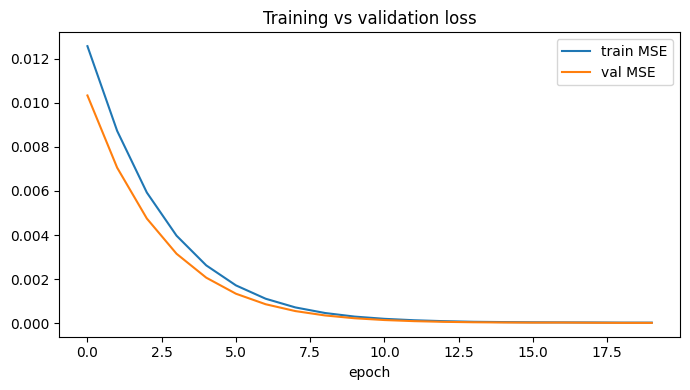

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history["loss"], label="train MSE")
ax.plot(history.history["val_loss"], label="val MSE")
ax.set_xlabel("epoch")
ax.set_title("Training vs validation loss")
ax.legend()
plt.tight_layout()
plt.show()


Test metrics (on min-max scaled targets): {'mae': 0.004509641213822945, 'rmse': 0.03269548462543173, 'r2': 0.756240387515575}


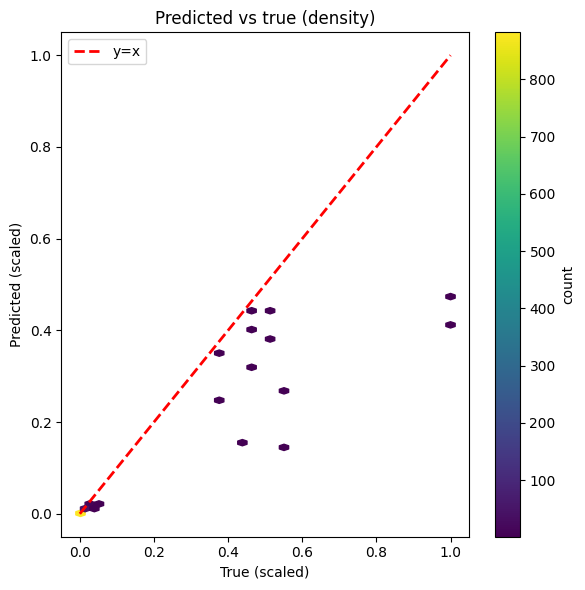

In [9]:
predictions = model.predict(
    [
        test_data["temporal_sequences"].astype(np.float32),
        test_data["trend_sequences"].astype(np.float32),
        test_static_encoded,
    ],
    verbose=0,
)
predictions = np.squeeze(predictions)

hybrid_metrics = calculate_metrics_np(test_data["output_sequences"], predictions)
print("Test metrics (on min-max scaled targets):", hybrid_metrics)

y_true_f = np.asarray(test_data["output_sequences"]).flatten()
y_pred_f = np.asarray(predictions).flatten()
plt.figure(figsize=(6, 6))
plt.hexbin(y_true_f, y_pred_f, gridsize=40, cmap="viridis", mincnt=1)
plt.plot([0, 1], [0, 1], "r--", lw=2, label="y=x")
plt.xlabel("True (scaled)")
plt.ylabel("Predicted (scaled)")
plt.title("Predicted vs true (density)")
plt.legend()
plt.colorbar(label="count")
plt.tight_layout()
plt.show()


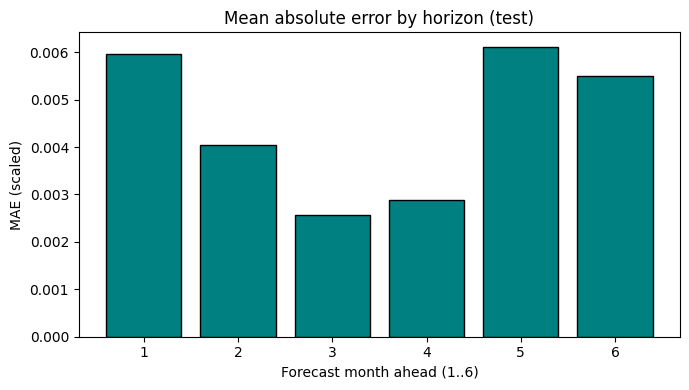

In [10]:
# Per forecast horizon MAE (still in scaled space)
horizon_mae = np.mean(np.abs(test_data["output_sequences"] - predictions), axis=0)
plt.figure(figsize=(7, 4))
plt.bar(np.arange(1, len(horizon_mae) + 1), horizon_mae, color="teal", edgecolor="black")
plt.xlabel("Forecast month ahead (1..6)")
plt.ylabel("MAE (scaled)")
plt.title("Mean absolute error by horizon (test)")
plt.tight_layout()
plt.show()


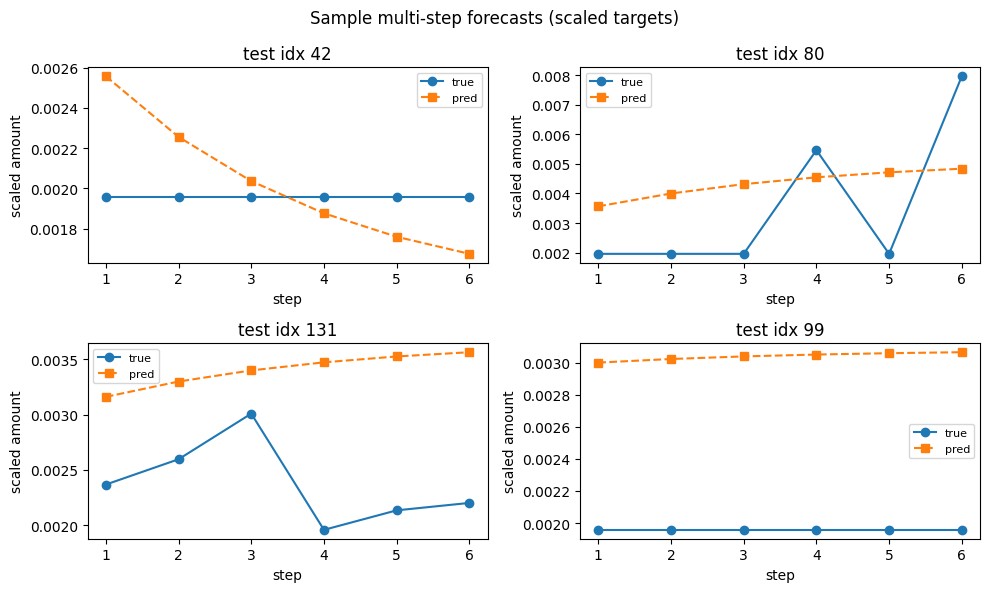

In [11]:
# Example: predicted vs true sequences for a few test rows
n_show = 4
rng = np.random.default_rng(0)
pick = rng.choice(len(test_data["output_sequences"]), size=n_show, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
h = np.arange(1, test_data["output_sequences"].shape[1] + 1)
for ax, row in zip(axes, pick):
    ax.plot(h, test_data["output_sequences"][row], "o-", label="true", color="C0")
    ax.plot(h, predictions[row], "s--", label="pred", color="C1")
    ax.set_xticks(h)
    ax.set_xlabel("step")
    ax.set_ylabel("scaled amount")
    ax.legend(fontsize=8)
    ax.set_title(f"test idx {row}")
plt.suptitle("Sample multi-step forecasts (scaled targets)")
plt.tight_layout()
plt.show()


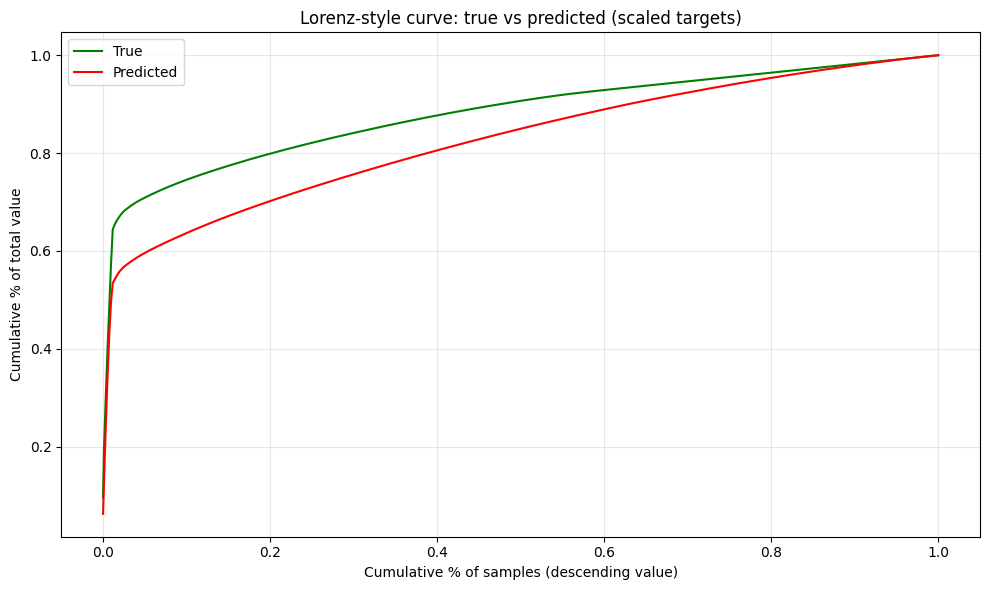

Mutual Gini (lower is better): 0.0546


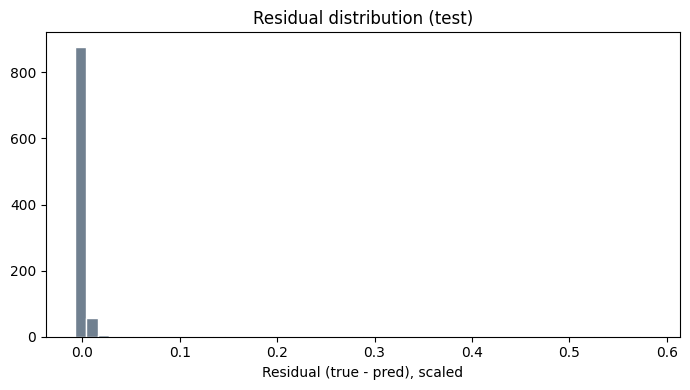

In [12]:
_ = plot_lorenz_analysis(test_data["output_sequences"], predictions)

residuals = (test_data["output_sequences"] - predictions).flatten()
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50, color="slategray", edgecolor="white")
plt.xlabel("Residual (true - pred), scaled")
plt.title("Residual distribution (test)")
plt.tight_layout()
plt.show()
